# Comparison of different post-processing technqiues, presenting RPCA

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

%matplotlib inline

In [2]:
datasetID = '26_04_2024_5'
campaignID = '2024_ESASnowDrone'

RADAR = load_RADAR(radar_type='UWiBaSS',
                   datasetID=datasetID,
                   campaignID=campaignID,
                   yaml_file="./campaigns.yaml"
                   )


Dataset 26_04_2024_5 from campaign 2024_ESASnowDrone is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/26_04_2024_5/uwibass_object.pkl


Make SVD more sophisticated (Experiemtn with different nr of removed components etc)

In [119]:
svd_dict = {}
# p=2; # Bandpass SVD: p=2..5 q=10..100 || Lowpass SVD: p=1  q=3...100
p = 0

for q in trange(1, 20, 1):
    
    rxsvd = np.copy(RADAR.rxraw[:,2000:12000])
    
    U,S,V = scipy.linalg.svd(rxsvd,full_matrices=False)
    
    s = S[np.nonzero(S)]
    svd_dict[f'SVD, {q}'] = rxsvd - U[:, p:q] @ np.diag(s[p:q]) @ V[p:q, :]


100%|██████████| 19/19 [01:27<00:00,  4.60s/it]


Mean-filtered 

In [6]:
rx_mean = np.array(RADAR.rxraw[:,2000:12000] - np.einsum('ij->i',RADAR.rxraw)[:,None]/RADAR.rxraw.shape[1])

Get the RPCA results

In [ ]:
S_dict = {}
for lambdi in tqdm([0.25, 0.5, 1]):
    _, S = rpca_pcp_ialm(
        RADAR.rxraw[:,2000:12000],
        sparsity_factor=lambdi/ np.sqrt(max(RADAR.rxraw[:,2000:12000].shape)),
        verbose=False
    )

    S_dict[f'RPCA, {lambdi}'] = S

100%|██████████| 1/1 [01:24<00:00, 84.96s/it]


In [7]:
top_path = RADAR.PF_top_interface[2000:12000]
bottom_path = RADAR.PF_bottom_interface[2000:12000]

Echogram plot

Text(0.0, 1, 'RPCA (Sparse component, $\\lambda=1.00$)')

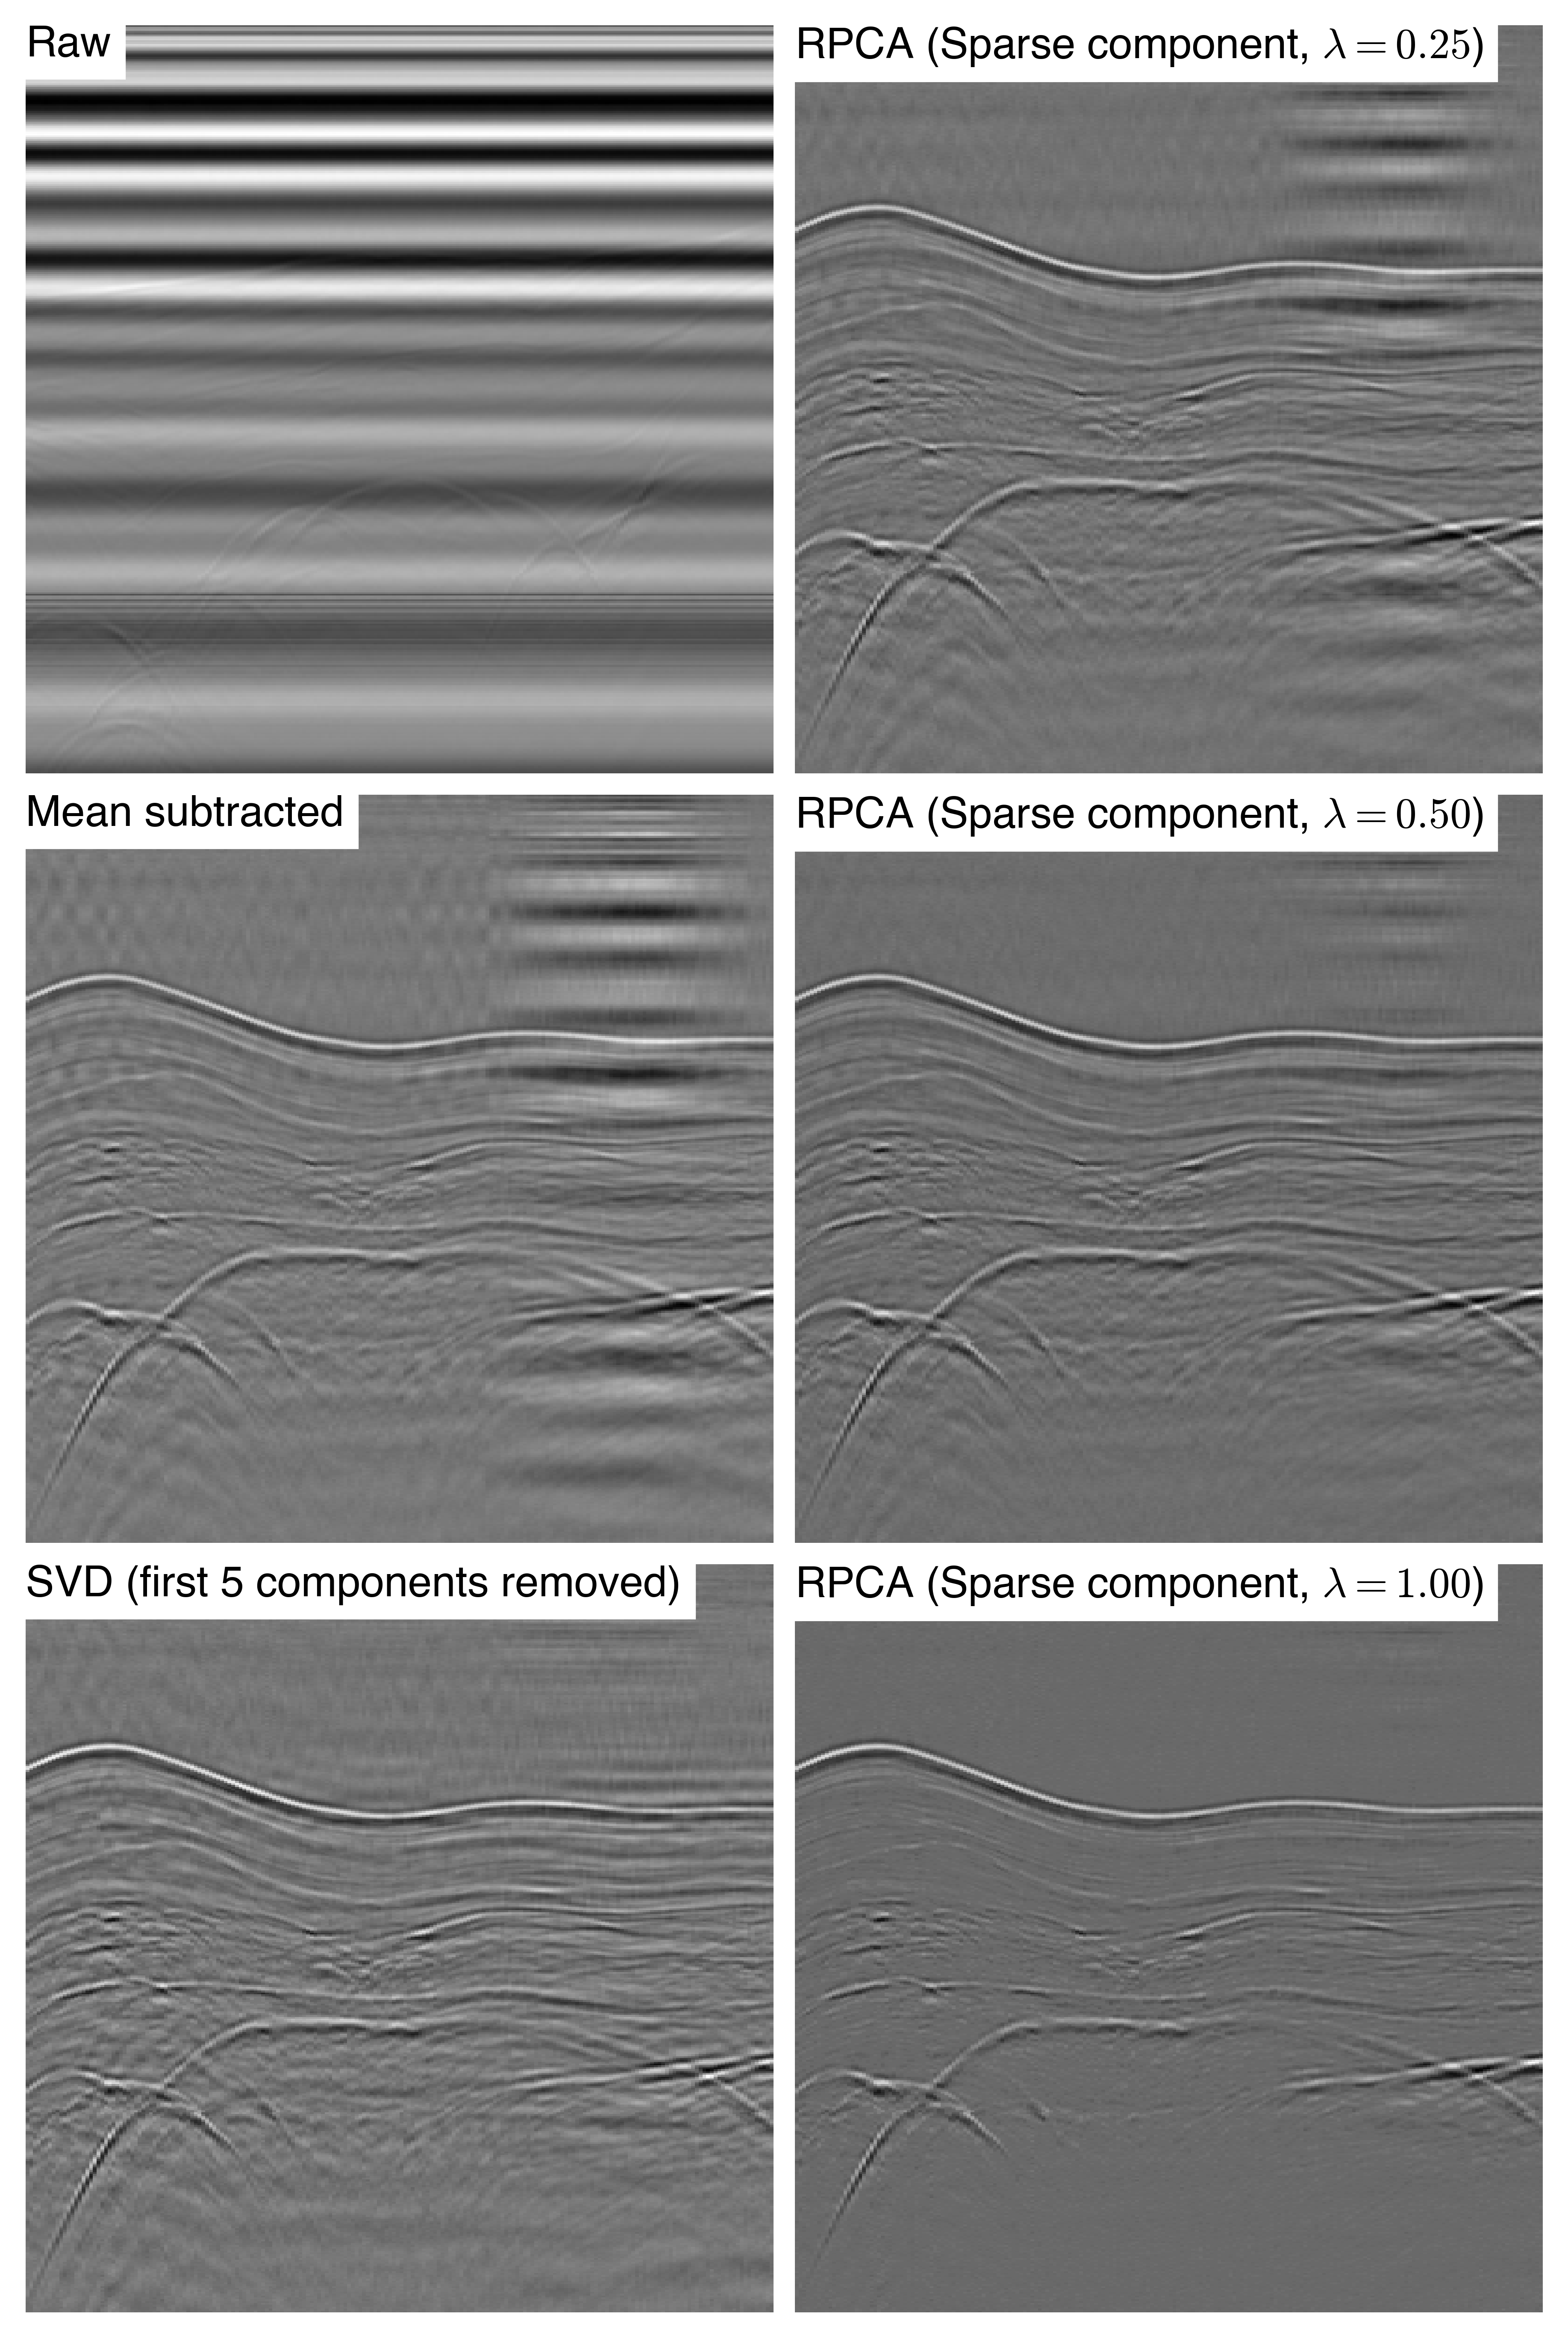

In [ ]:
%matplotlib inline

sind = 5050
fig, ax = plt.subplots(3,2, figsize=(6, 9), constrained_layout=True, dpi=600)

ax = ax.ravel()

for a in ax:
    a.axis('off')
    
ax[0].imshow(RADAR.rxraw[0:400, sind:sind+200], cmap='grey', aspect=.5)
ax[2].imshow(svd_dict['SVD, 1'][0:400, sind+2000:sind+2200], cmap='grey', aspect=.5)
ax[4].imshow(svd_dict['SVD, 5'][0:400, sind+2000:sind+2200], cmap='grey', aspect=.5)
ax[1].imshow(S_dict['RPCA, 0.25'][0:400, sind+2000:sind+2200], cmap='grey', aspect=.5)
ax[3].imshow(S_dict['RPCA, 0.5'][0:400, sind+2000:sind+2200], cmap='grey', aspect=.5)
ax[5].imshow(S_dict['RPCA, 1'][0:400, sind+2000:sind+2200], cmap='grey', aspect=.5)

props = dict(boxstyle='square', facecolor='white', edgecolor='white')

ax[0].text(0.0, 1, 'Raw', transform=ax[0].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

ax[2].text(0.0, 1, 'Mean subtracted', transform=ax[2].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

ax[4].text(0.0, 1, 'SVD (first 5 components removed)' , transform=ax[4].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

ax[1].text(0.0, 1, 'RPCA (Sparse component, $\\lambda=0.25$)', transform=ax[1].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

ax[3].text(0.0, 1, 'RPCA (Sparse component, $\\lambda=0.50$)', transform=ax[3].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

ax[5].text(0.0, 1, 'RPCA (Sparse component, $\\lambda=1.00$)', transform=ax[5].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

OLD STUFF FOR SNR BELOW

In [ ]:
def flatten_to_interface(arr, uwibass, interface='bottom', smoothing_window=5, reduce=False, startind=0, endind=None):
    
    """
    Flatten the radargram to a specific interface (top or bottom) based on the UWIbass object.
    
    Parameters:
    - arr: 2D numpy array of the radargram
    - uwibass: UWIbass object containing the interfaces
    - interface: 'top' or 'bottom' to specify which interface to flatten to
    
    Returns:
    - flattened_arr: 2D numpy array flattened to the specified interface
    """
    
    if interface == 'top':
        interface_indices = np.convolve(uwibass.PF_top_interface[startind:endind], np.ones(smoothing_window)/smoothing_window, mode='same').astype(int)
        sign = -1
        
    elif interface == 'bottom':
        interface_indices = np.convolve(uwibass.PF_bottom_interface[startind:endind], np.ones(smoothing_window)/smoothing_window, mode='same').astype(int)
        sign = -1  # Roll down for bottom interface
        
    else:
        raise ValueError("Interface must be 'top' or 'bottom'")
    
    flattened_arr = np.zeros_like(arr)
    
    for i in range(arr.shape[1]):
        flattened_arr[:, i] = np.roll(arr[:, i], sign * interface_indices[i])
    
    
    if reduce:
        valid_rows = ~np.all(np.isnan(flattened_arr), axis=1)
        flattened_arr = flattened_arr[valid_rows]
        
    return flattened_arr

def get_noise_levels(data, uwibass, startind, endind):
    
    air_signal = flatten([
            data[:uwibass.PF_top_interface[startind:endind][i], i]
            for i in range(data.shape[1])
        ])
    
    flattened_section = flatten_to_interface(data, uwibass,
                            interface='top',
                            smoothing_window=3,
                            reduce=False,
                            startind=startind,
                            endind=endind
                            )

    flattened_bottom_trace = pd.Series(uwibass.PF_bottom_interface[startind:endind]).rolling(window=3, min_periods=0, center=True).mean().astype(int)- pd.Series(uwibass.PF_top_interface[startind:endind]).rolling(window=3, min_periods=0, center=True).mean().astype(int)

    snow_signal = mask_path_in_cost(flattened_section,
                                zip(flattened_bottom_trace, range(len(uwibass.PF_bottom_interface[startind:endind]))),
                                radius=2, #TODO: BASE THIS ON PHYSICS (Expected range resolution)
                                strength=np.inf
                                )
    snow_signal = mask_cost_below_above_path(snow_signal,
                                            zip(flattened_bottom_trace, range(len(uwibass.PF_bottom_interface[startind:endind]))),
                                            np.inf,
                                            layer='bottom'
                                            )

    snow_signal[np.isinf(snow_signal)] = np.nan
    snow_signal = snow_signal.flatten()
    snow_signal = snow_signal[~np.isnan(snow_signal)]

    return air_signal, snow_signal

    

In [ ]:
power_at_top = {}
power_at_bottom = {}
power_fraction = {}
air_noise_level = {}
snow_noise_level = {}

power_at_top['Mean'] = rx_mean[top_path,range(len(top_path))]
power_at_bottom['Mean'] = rx_mean[bottom_path,range(len(bottom_path))]
power_fraction['Mean'] = np.abs(power_at_top['Mean']) / np.abs(power_at_bottom['Mean'])
air_noise_level['Mean'], snow_noise_level['Mean'] = get_noise_levels(rx_mean, RADAR, startind=2000, endind=12000)

for key in tqdm(svd_dict.keys()):
    rxsvd = svd_dict[key]
    power_at_top[key]= rxsvd[top_path,range(len(top_path))]
    power_at_bottom[key]= rxsvd[bottom_path,range(len(bottom_path))]
    power_fraction[key] = np.abs(power_at_top[key]) / np.abs(power_at_bottom[key])
    air_noise_level[key], snow_noise_level[key] = get_noise_levels(rxsvd, RADAR, startind=2000, endind=12000)

for lambdi in tqdm(S_dict.keys()):    
    S = S_dict[lambdi]
    power_at_top[lambdi]= S_dict[lambdi][top_path,range(len(top_path))]
    power_at_bottom[lambdi]= S_dict[lambdi][bottom_path,range(len(bottom_path))]
    power_fraction[lambdi] = np.abs(power_at_top[lambdi]) / np.abs(power_at_bottom[lambdi])
    air_noise_level[lambdi], snow_noise_level[lambdi] = get_noise_levels(S_dict[lambdi], RADAR, startind=2000, endind=12000)

In [ ]:
from matplotlib.colors import BoundaryNorm

# svd_cmap = plt.get_cmap('summer')
# svd_norm = plt.Normalize(vmin=2, vmax=9)

# rpca_cmap = plt.get_cmap('cool')
# rpca_norm = plt.Normalize(vmin=0.3, vmax=0.8)
# color_dict = {
#     'Mean': 'black',
#     '0, 1': svd_cmap(svd_norm(1)),
#     '0, 2': svd_cmap(svd_norm(2)),
#     '0, 3': svd_cmap(svd_norm(3)),
#     '0, 4': svd_cmap(svd_norm(4)),
#     '0, 5': svd_cmap(svd_norm(5)),
#     '0, 6': svd_cmap(svd_norm(6)),
#     '0, 7': svd_cmap(svd_norm(7)),
#     '0, 8': svd_cmap(svd_norm(8)),
#     '0, 9': svd_cmap(svd_norm(9)),

#     0.3: rpca_cmap(rpca_norm(0.3)),
#     0.4: rpca_cmap(rpca_norm(0.4)),
#     0.5: rpca_cmap(rpca_norm(0.5)),
#     0.6: rpca_cmap(rpca_norm(0.6)),
#     0.7: rpca_cmap(rpca_norm(0.7)),
#     0.8: rpca_cmap(rpca_norm(0.8)),
    
# }


fig, ax = plt.subplots(3, 1, figsize=(5,8), sharex=True)

for a in ax:
    a.grid(axis='x', ls=':', color='gray')
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    
positions = list(range(len(power_fraction.keys())))
labels = [str(k) for k in power_fraction.keys()]


vals_1 = []
vals_2 = []
vals_3 = []
vals_4 = []
for key in svd_dict.keys():
    vals_1.append(np.nanmean(np.array(power_at_top[key])**2))
    vals_2.append(np.nanmean(np.array(power_at_bottom[key])**2))
    vals_3.append(np.nanmean(np.array(air_noise_level[key])**2))
    vals_4.append(np.nanmean(np.array(snow_noise_level[key])**2))
ax[0].plot(range(1, 1+len(svd_dict.keys())), vals_1, color='blue', zorder=0, lw=2, alpha=.2)
ax[0].plot(range(1, 1+len(svd_dict.keys())), vals_2, color='orange', zorder=0, lw=2, alpha=.2)
ax[1].plot(range(1, 1+len(svd_dict.keys())), vals_3, color='blue', zorder=0, lw=2, alpha=.2)
ax[1].plot(range(1, 1+len(svd_dict.keys())), vals_4, color='orange', zorder=0, lw=2, alpha=.2)


vals_1 = []
vals_2 = []
vals_3 = []
vals_4 = []
for key in S_dict.keys():
    vals_1.append(np.nanmean(np.array(power_at_top[key])**2))
    vals_2.append(np.nanmean(np.array(power_at_bottom[key])**2))
    vals_3.append(np.nanmean(np.array(air_noise_level[key])**2))
    vals_4.append(np.nanmean(np.array(snow_noise_level[key])**2))
ax[0].plot(range(len(svd_dict.keys()) + 1, len(svd_dict.keys()) + len(S_dict.keys()) + 1), vals_1, color='blue', zorder=0, lw=2, alpha=.2)
ax[0].plot(range(len(svd_dict.keys()) + 1, len(svd_dict.keys()) + len(S_dict.keys()) + 1), vals_2, color='orange', zorder=0, lw=2, alpha=.2)
ax[1].plot(range(len(svd_dict.keys()) + 1, len(svd_dict.keys()) + len(S_dict.keys()) + 1), vals_3, color='blue', zorder=0, lw=2, alpha=.2)
ax[1].plot(range(len(svd_dict.keys()) + 1, len(svd_dict.keys()) + len(S_dict.keys()) + 1), vals_4, color='orange', zorder=0, lw=2, alpha=.2)


for idx, key in enumerate(power_fraction.keys()):
    ax[0].scatter(idx, np.nanmean(np.array(power_at_top[key])**2), color='blue', clip_on=False, zorder=100)
    ax[1].scatter(idx, np.nanmean(np.array(air_noise_level[key])**2), color='blue', clip_on=False, zorder=100)

    ax[0].scatter(idx, np.nanmean(np.array(power_at_bottom[key])**2), color='orange', clip_on=False, zorder=100)
    ax[1].scatter(idx, np.nanmean(np.array(snow_noise_level[key])**2), color='orange', clip_on=False, zorder=100)



    ax[2].scatter(idx, np.nanmean(np.array(power_at_top[key])**2) / np.nanmean(np.array(air_noise_level[key])**2),
                  color='blue', clip_on=False,
                  zorder=100)
    
    ax[2].scatter(idx, np.nanmean(np.array(power_at_bottom[key])**2) / np.nanmean(np.array(snow_noise_level[key])**2),
                  color='orange', clip_on=False,
                  zorder=100)



ax[0].set_xticks(positions)
ax[0].set_xticklabels(labels, rotation=90, )

ax[1].set_xticks(positions)
ax[1].set_xticklabels(labels, rotation=90,)

ax[2].set_xticks(positions)
ax[2].set_xticklabels(labels, rotation=90,)

ax[0].set_title('Mean Power at Interfaces')
ax[1].set_title('Mean Noise Power Medium')
ax[2].set_title('SNR')

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Top Interface', markerfacecolor='blue', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Bottom Interface', markerfacecolor='orange', markersize=10)]
ax[0].legend(handles=legend_elements)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Air', markerfacecolor='blue', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Snow', markerfacecolor='orange', markersize=10)]
ax[1].legend(handles=legend_elements)

SNR plot

Text(0.025, 0.975, '(b)')

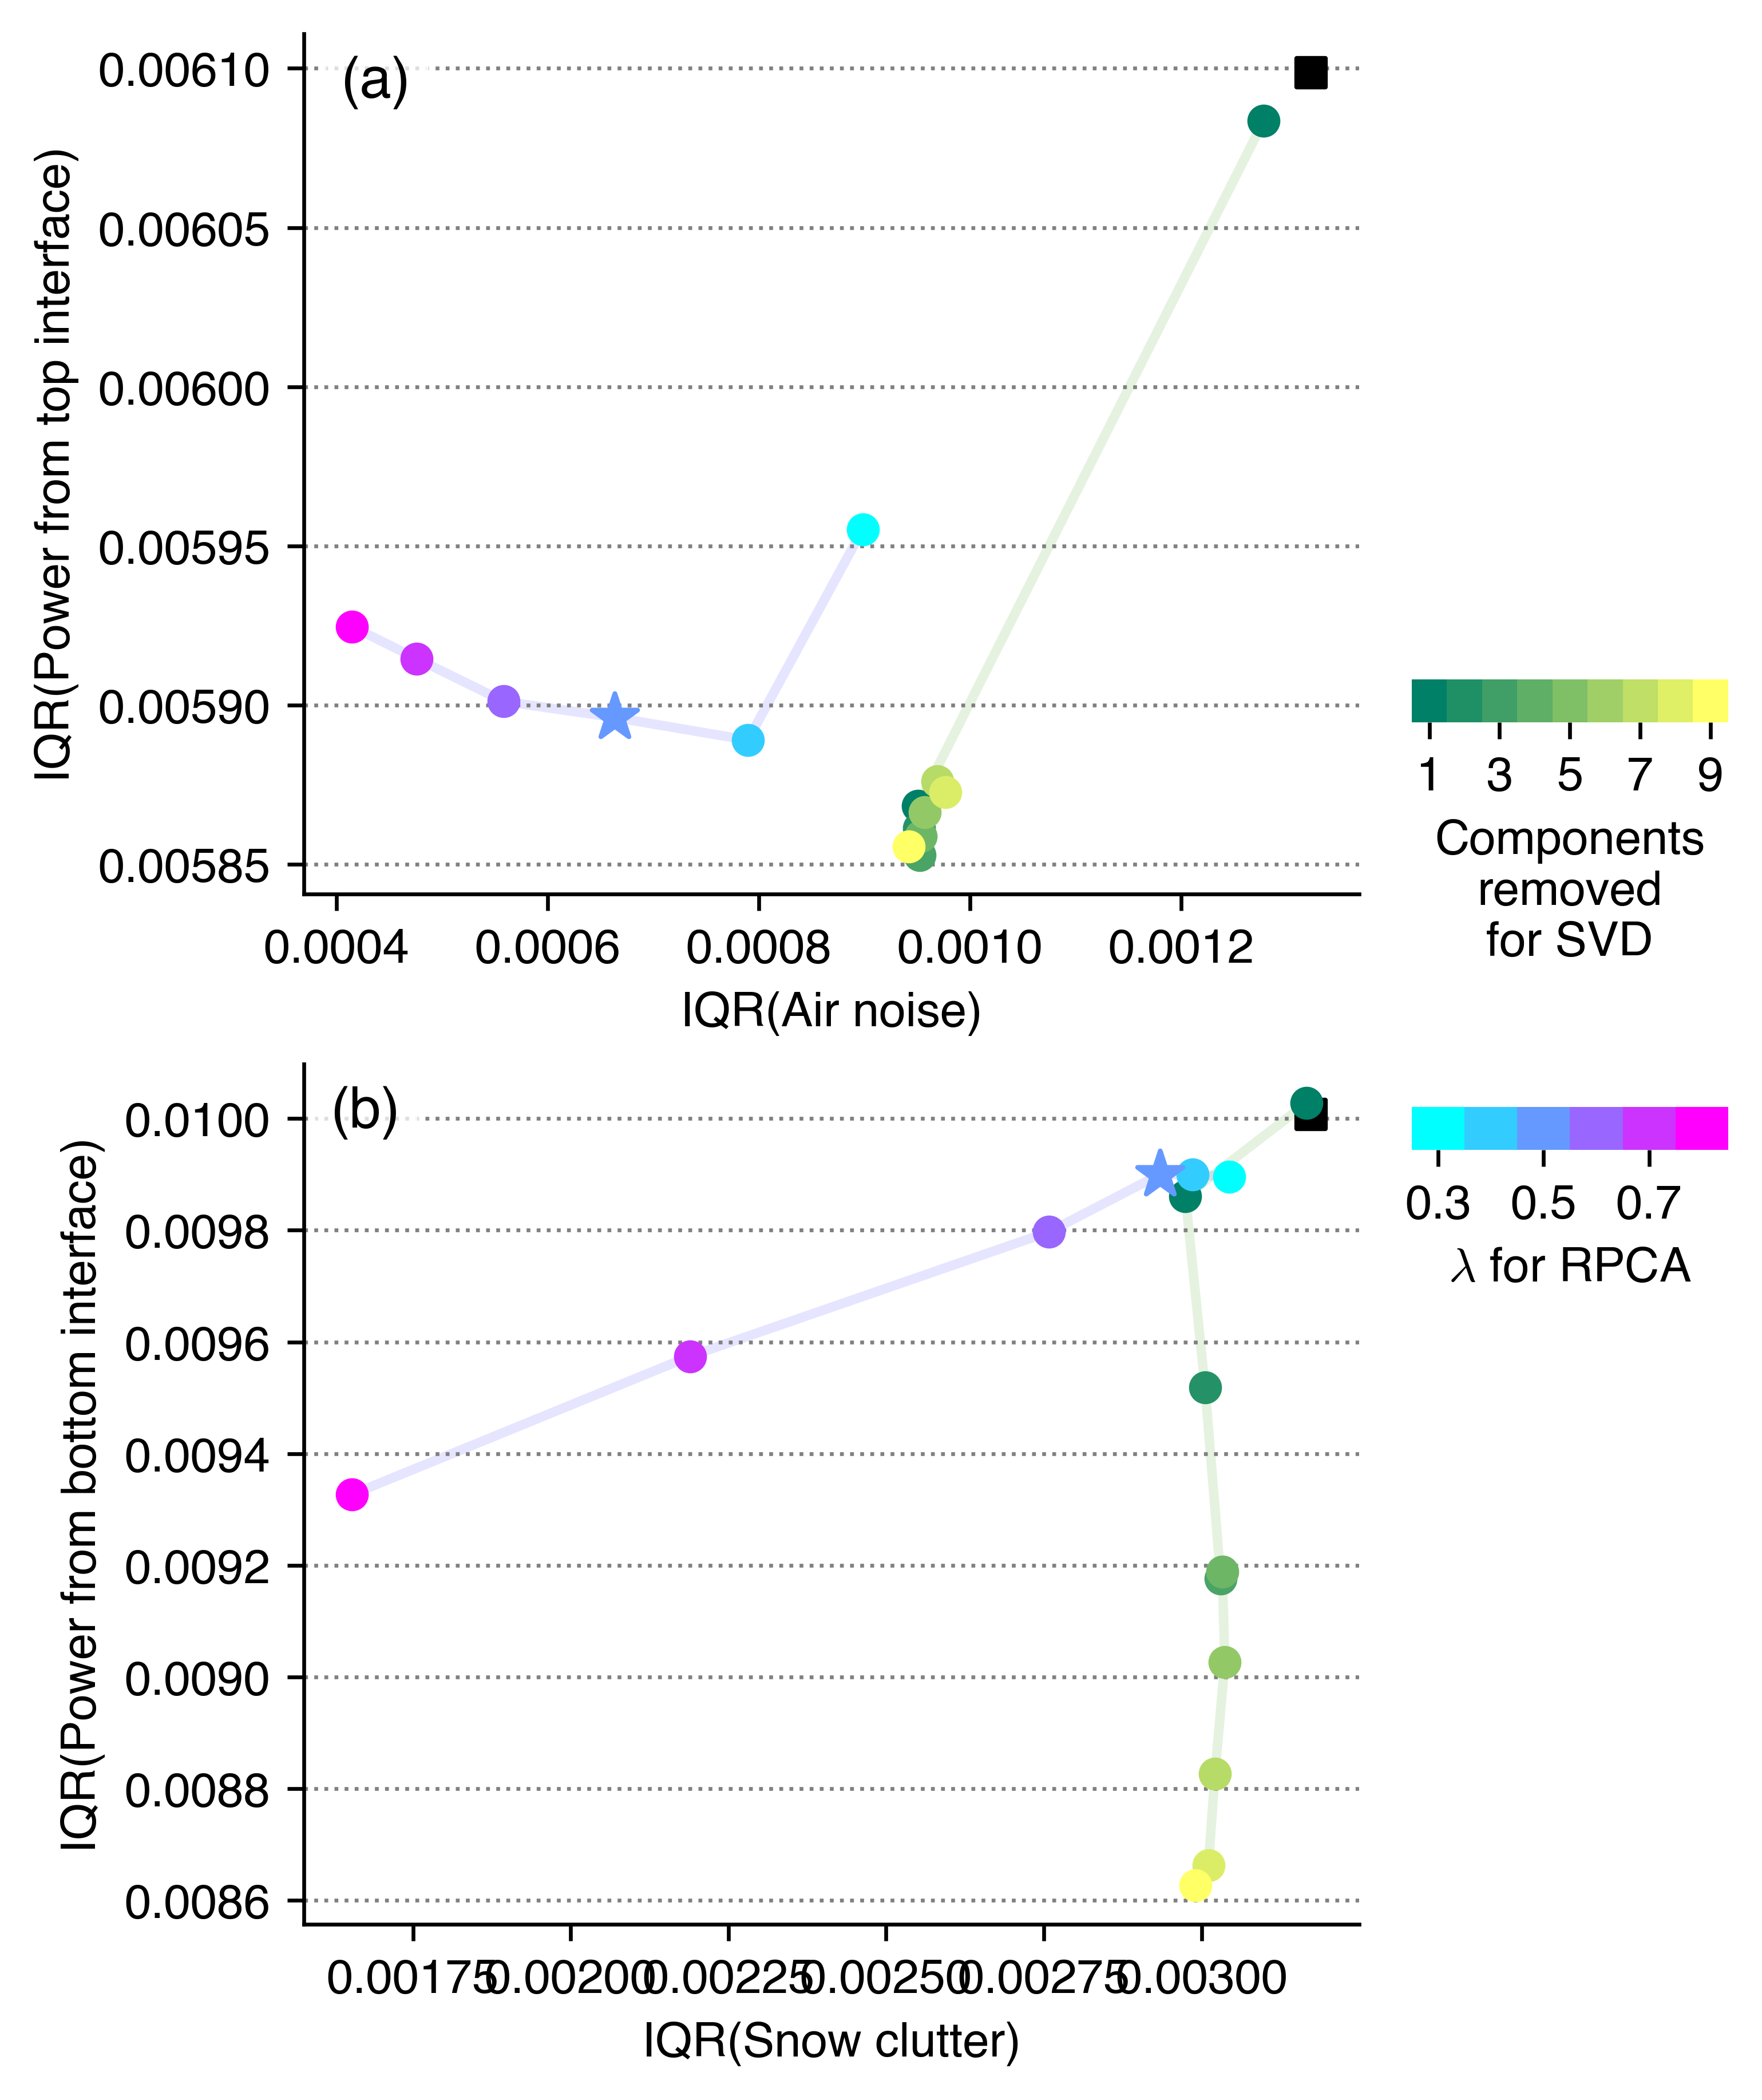

In [216]:
from matplotlib.colors import BoundaryNorm

svd_cmap = plt.get_cmap('summer')
svd_norm = plt.Normalize(vmin=2, vmax=9)

rpca_cmap = plt.get_cmap('cool')
rpca_norm = plt.Normalize(vmin=0.3, vmax=0.8)
color_dict = {
    'Mean': 'black',
    '0, 1': svd_cmap(svd_norm(1)),
    '0, 2': svd_cmap(svd_norm(2)),
    '0, 3': svd_cmap(svd_norm(3)),
    '0, 4': svd_cmap(svd_norm(4)),
    '0, 5': svd_cmap(svd_norm(5)),
    '0, 6': svd_cmap(svd_norm(6)),
    '0, 7': svd_cmap(svd_norm(7)),
    '0, 8': svd_cmap(svd_norm(8)),
    '0, 9': svd_cmap(svd_norm(9)),

    0.3: rpca_cmap(rpca_norm(0.3)),
    0.4: rpca_cmap(rpca_norm(0.4)),
    0.5: rpca_cmap(rpca_norm(0.5)),
    0.6: rpca_cmap(rpca_norm(0.6)),
    0.7: rpca_cmap(rpca_norm(0.7)),
    0.8: rpca_cmap(rpca_norm(0.8)),
}


fig, ax = plt.subplots(2,1, figsize=(5,6), constrained_layout=True, dpi=600)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(color='grey', ls=':', axis='y', zorder=0)
    
for key in power_fraction.keys():
    if key == '0, 0':
        continue
    ax[0].scatter(np.quantile(air_noise_level[key], 0.75) - np.quantile(air_noise_level[key], 0.25),
                  np.quantile(power_at_top[key], 0.75) - np.quantile(power_at_top[key], 0.25),
                  color=color_dict[key],
                  s=100 if key==0.5 else 35,
                  marker='s' if key == 'Mean' else ('*' if key == 0.5 else 'o'),
                  zorder=1000
                  
                  )
x = []
y = []
for key in S_dict.keys():
    x.append(np.quantile(air_noise_level[key], 0.75) - np.quantile(air_noise_level[key], 0.25))
    y.append(np.quantile(power_at_top[key], 0.75) - np.quantile(power_at_top[key], 0.25))
ax[0].plot(x, y, color=rpca_cmap(0.5), zorder=0, lw=2, alpha=.2)

x = []
y = []
for key in svd_dict.keys():
    if key == '0, 0':
        continue
    x.append(np.quantile(air_noise_level[key], 0.75) - np.quantile(air_noise_level[key], 0.25))
    y.append(np.quantile(power_at_top[key], 0.75) - np.quantile(power_at_top[key], 0.25))
ax[0].plot(x, y, color=svd_cmap(0.5), zorder=0, lw=2, alpha=.2)



ax[0].set_xlabel('IQR(Air noise)')
ax[0].set_ylabel('IQR(Power from top interface)')

for key in power_fraction.keys():
    if key == '0, 0':
        continue
    ax[1].scatter(np.quantile(snow_noise_level[key], 0.75) - np.quantile(snow_noise_level[key], 0.25),
                  np.quantile(power_at_bottom[key], 0.75) - np.quantile(power_at_bottom[key], 0.25),
                  color=color_dict[key],
                  s=100 if key==0.5 else 35,
                  marker='s' if key == 'Mean' else ('*' if key == 0.5 else 'o'),
                  zorder=1000
                  )

ax[1].set_xlabel('IQR(Snow clutter)')
ax[1].set_ylabel('IQR(Power from bottom interface)')



x = []
y = []
for key in S_dict.keys():
    x.append(np.quantile(snow_noise_level[key], 0.75) - np.quantile(snow_noise_level[key], 0.25))
    y.append(np.quantile(power_at_bottom[key], 0.75) - np.quantile(power_at_bottom[key], 0.25))
ax[1].plot(x, y, color=rpca_cmap(0.5), zorder=0, lw=2, alpha=.2)

x = []
y = []
for key in svd_dict.keys():
    if key == '0, 0':
        continue
    x.append(np.quantile(snow_noise_level[key], 0.75) - np.quantile(snow_noise_level[key], 0.25))
    y.append(np.quantile(power_at_bottom[key], 0.75) - np.quantile(power_at_bottom[key], 0.25))
ax[1].plot(x, y, color=(svd_cmap(0.5)), zorder=0, lw=2, alpha=.2)




inset_ax_svd_cbar = ax[0].inset_axes([1.05, 0.2, 0.3, 0.05])
svd_bounds = np.arange(1, 11)
svd_ticks = svd_bounds[::2] + 0.5
svd_discrete_norm = BoundaryNorm(svd_bounds, svd_cmap.N, clip=True)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=svd_discrete_norm, cmap=svd_cmap),
    cax=inset_ax_svd_cbar,
    orientation='horizontal',
    label='Components\nremoved\nfor SVD',
    ticks=svd_ticks    
)
cbar.outline.set_visible(False)
cbar.ax.set_xticklabels(range(1, 11, 2))
cbar.minorticks_off()


inset_ax_rpca_cbar = ax[1].inset_axes([1.05, 0.9, 0.3, 0.05])
rpca_bounds = np.arange(len(list(S_dict.keys())) + 1)  
rpca_ticks = rpca_bounds[::2] + 0.5
rpca_discrete_norm = BoundaryNorm(rpca_bounds, rpca_cmap.N, clip=True)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=rpca_discrete_norm, cmap=rpca_cmap),
    cax=inset_ax_rpca_cbar,
    orientation='horizontal',
    label='$\\lambda$ for RPCA',
    ticks=rpca_ticks
)
cbar.outline.set_visible(False)
cbar.ax.set_xticklabels([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9][::2])
cbar.minorticks_off()

props = dict(boxstyle='square', facecolor='white', edgecolor='white', alpha=.75)
ax[0].text(0.035, 0.975, '(a)', transform=ax[0].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)
ax[1].text(0.025, 0.975, '(b)', transform=ax[1].transAxes, fontsize=12,
        va='top', ha='left', bbox=props)